# Implied Carb Ratio vs Post-Meal Outcome — Stacked Bar Chart

Visualizes how meal outcomes (low, high, bolus timing off, and time-in-range buckets) distribute across implied carb ratio bins.  
**Implied carb ratio** = carbs logged (g) / insulin units administered.

## 1. Import Required Libraries

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 2. Generate Dummy Data

Synthetic patient meal records with:
- `carbs_g`: grams of carbohydrates logged per meal
- `insulin_units`: bolus insulin administered (units)
- `post_meal_glucose`: glucose reading ~2 h post-meal (mg/dL)
- `bolus_timing_offset_min`: minutes between bolus and meal start (positive = late, negative = pre-bolus)

In [134]:
rng = np.random.default_rng(seed=42)

# Three sub-populations reflecting the CR → outcome relationship:
#   Overdosed  (low ICR  → went low)  mean ICR = 9
#   Well-dosed (ideal     → in range)  mean ICR = 10
#   Underdosed (high ICR → went high) mean ICR = 11
SD_IDEAL = 0.5
SD_LOW = SD_IDEAL - 0.1
SD_HIGH = SD_IDEAL - 0.1
N_IDEAL = 180  # meals per group (270 total)
N_LOW = 30
N_HIGH = 60
N = N_LOW + N_IDEAL + N_HIGH

icr_low = rng.normal(9, SD_LOW, N_LOW)  # overdosed → low glucose
icr_ideal = rng.normal(10.0, SD_IDEAL, N_IDEAL)  # well-dosed → in range
icr_high = rng.normal(11, SD_HIGH, N_HIGH)  # underdosed → high glucose

# Post-meal glucose matching each group's dosing pattern
glucose_low = rng.normal(90, 4, N_LOW)  # trending low
glucose_ideal = rng.normal(125, 5, N_IDEAL)  # in range
glucose_high = rng.normal(160, 4, N_HIGH)  # trending high

implied_icr = np.concatenate([icr_low, icr_ideal, icr_high])
post_meal_glucose = np.concatenate([glucose_low, glucose_ideal, glucose_high])

carbs_g = rng.uniform(15, 100, N)
insulin_units = carbs_g / implied_icr

# Shuffle rows so groups are interleaved
idx = rng.permutation(N)
implied_icr, post_meal_glucose = implied_icr[idx], post_meal_glucose[idx]
carbs_g, insulin_units = carbs_g[idx], insulin_units[idx]

df = pd.DataFrame(
    {
        "carbs_g": carbs_g,
        "insulin_units": insulin_units,
        "post_meal_glucose": post_meal_glucose,
        "implied_icr": implied_icr,
    }
)

print(f"Records: {len(df)}")
print(
    f"ICR  mean={df['implied_icr'].mean():.2f}  std={df['implied_icr'].std():.2f}  "
    f"min={df['implied_icr'].min():.2f}  max={df['implied_icr'].max():.2f}"
)
df.head()

Records: 270
ICR  mean=10.09  std=0.71  min=8.22  max=12.16


,carbs_g,insulin_units,post_meal_glucose,implied_icr
0,74.757845,7.076335,119.735507,10.564486
1,88.334988,8.737654,126.743879,10.109691
2,45.730567,4.143689,158.765308,11.036196
3,19.161915,1.981781,129.232920,9.669037
4,81.945136,8.398732,117.597317,9.756846


## 3. Compute Implied Carb Ratio Bins

Three sub-populations, each with SD ≈ 0.75:
- **Went Low** meals centred at ICR = 8 (overdosed)
- **Ideal** meals centred at ICR = 10 (well-dosed)
- **Went High** meals centred at ICR = 12 (underdosed)

Bins: 0.5-unit steps from 5 to 15 → **20 bars**.

In [135]:
# Bins cover the realistic ICR range of the mixture (5–15) at 0.25-unit steps → 40 bars
bin_edges = np.arange(5.0, 15.25, 0.25)  # 41 edges → 40 bins
bin_labels = [f"{e:.2f}" for e in np.arange(5.0, 15.0, 0.25)]  # 40 left-edge labels

df["icr_bin"] = pd.cut(
    df["implied_icr"],
    bins=bin_edges,
    labels=bin_labels,
    right=False,
)

print(df["icr_bin"].value_counts().sort_index())

icr_bin
5.00      0
5.25      0
5.50      0
5.75      0
6.00      0
6.25      0
6.50      0
6.75      0
7.00      0
7.25      0
7.50      0
7.75      0
8.00      1
8.25      1
8.50      5
8.75      9
9.00     13
9.25     27
9.50     28
9.75     42
10.00    40
10.25    31
10.50    20
10.75    23
11.00    17
11.25     6
11.50     3
11.75     2
12.00     2
12.25     0
12.50     0
12.75     0
13.00     0
13.25     0
13.50     0
13.75     0
14.00     0
14.25     0
14.50     0
14.75     0
Name: count, dtype: int64


## 4. Categorize Post-Meal Outcomes

Each meal is assigned one of **7 mutually exclusive categories**:

| Category | Fill | Condition |
|---|---|---|
| TIR 100% | Solid green | Gaussian probability peaking at ICR = 10 |
| TIR 85–100% (Low) | Sky blue `///` | tir ≥ 0.85, glucose trended low (< 125) |
| TIR 85–100% (High) | Sky blue `\\\` | tir ≥ 0.85, glucose trended high (≥ 125) |
| TIR 70–85% (Low) | Yellow `///` | tir ≥ 0.70, glucose trended low |
| TIR 70–85% (High) | Yellow `\\\` | tir ≥ 0.70, glucose trended high |
| TIR <70% (Low) | Orange `///` | tir < 0.70, glucose trended low |
| TIR <70% (High) | Orange `\\\` | tir < 0.70, glucose trended high |

Same color = same TIR bucket. Hatch direction encodes glucose trend (Low `///` vs High `\\\`).

In [136]:
GLUCOSE_MID = (
    125  # midpoint of 70–180 range; below = trending low, above = trending high
)

# ── TIR 100% probability ────────────────────────────────────────────────────
# Peaks at ICR = 10 (ideal ratio), decays with a Gaussian kernel
icr_z = (df["implied_icr"] - 10.0) / 0.8  # narrow spread
tir100_prob = np.exp(-0.5 * icr_z**2) * 0.75  # high peak → more qualify near center

tir100_draw = rng.uniform(0, 1, len(df))
df["is_tir100"] = tir100_draw < tir100_prob

# ── TIR fraction for remaining meals ────────────────────────────────────────
glucose_deviation = np.abs(df["post_meal_glucose"] - GLUCOSE_MID) / 55
alpha_p = np.clip(3.0 - glucose_deviation * 5, 0.3, 3.0)
beta_p = np.clip(1.0 + glucose_deviation * 3, 1.0, 4.0)
tir_fraction = rng.beta(alpha_p, beta_p)
df["tir_fraction"] = tir_fraction

# ── Assign direction: did the meal trend low or high? ───────────────────────
df["direction"] = np.where(df["post_meal_glucose"] < GLUCOSE_MID, "Low", "High")


def assign_outcome(row):
    if row["is_tir100"]:
        return "TIR 100%"
    d = row["direction"]
    tir = row["tir_fraction"]
    if tir >= 0.85:
        return f"TIR 85\u2013100% ({d})"
    if tir >= 0.70:
        return f"TIR 70\u201385% ({d})"
    return f"TIR <70% ({d})"


df["outcome"] = df.apply(assign_outcome, axis=1)
print(df["outcome"].value_counts())

outcome
TIR 100%              149
TIR <70% (High)        52
TIR <70% (Low)         40
TIR 85–100% (High)     11
TIR 70–85% (Low)        7
TIR 70–85% (High)       7
TIR 85–100% (Low)       4
Name: count, dtype: int64


## 5. Aggregate Counts by Carb Ratio Bin and Outcome

In [137]:
OUTCOME_ORDER = [
    "TIR 100%",
    "TIR 85\u2013100% (Low)",
    "TIR 85\u2013100% (High)",
    "TIR 70\u201385% (Low)",
    "TIR 70\u201385% (High)",
    "TIR <70% (Low)",
    "TIR <70% (High)",
]

pivot = (
    df.groupby(["icr_bin", "outcome"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=OUTCOME_ORDER, fill_value=0)
)

print(pivot)

outcome  TIR 100%  TIR 85–100% (Low)  TIR 85–100% (High)  TIR 70–85% (Low)  \
icr_bin                                                                      
8.00            0                  0                   0                 0   
8.25            0                  0                   0                 0   
8.50            0                  0                   0                 0   
8.75            4                  0                   0                 0   
9.00            4                  0                   1                 0   
9.25           18                  0                   1                 0   
9.50           20                  0                   0                 1   
9.75           30                  2                   1                 1   
10.00          25                  2                   4                 2   
10.25          17                  0                   3                 1   
10.50          12                  0                   1        

## 6. Plot Stacked Bar Chart

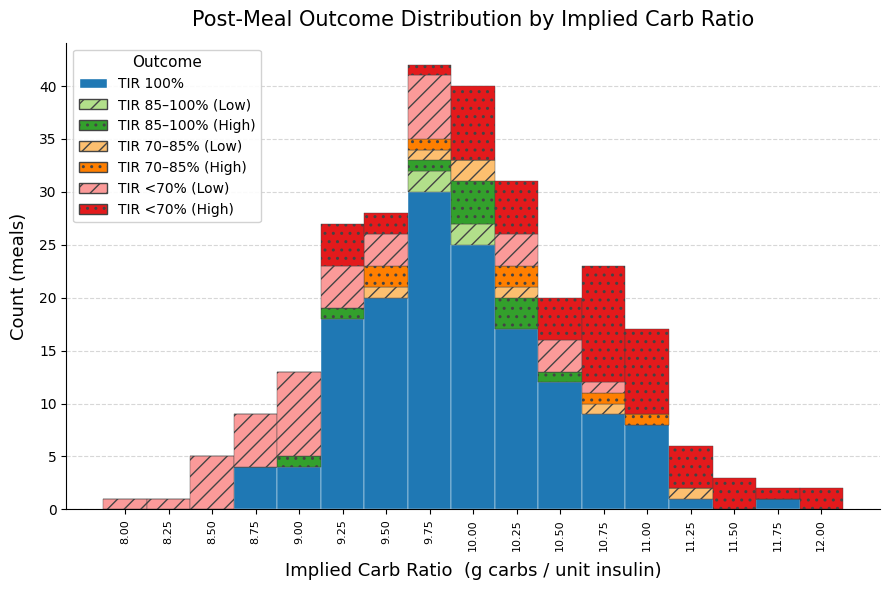

In [139]:
# ── Paired colormap ─────────────────────────────────────────────────────────
# Extract the 12 Paired colors: arranged as (light, dark) pairs
# 0-1: blues, 2-3: greens, 4-5: reds, 6-7: oranges
_p = plt.cm.Paired.colors  # tuple of 12 RGB tuples

LIGHT_BLUE, DARK_BLUE = _p[0], _p[1]
LIGHT_GREEN, DARK_GREEN = _p[2], _p[3]
LIGHT_RED, DARK_RED = _p[4], _p[5]
LIGHT_ORANGE, DARK_ORANGE = _p[6], _p[7]


# ── Style definitions ────────────────────────────────────────────────────────
# Color hue  → TIR quality  (green=100%, blue=85-100%, orange=70-85%, red=<70%)
# Light/dark → direction    (light=Low, dark=High)
# Hatch      → direction    (//=Low, *=High) — redundant encoding for accessibility
OUTCOME_STYLES = {
    "TIR 100%": {"color": DARK_BLUE, "hatch": None},  # solid dark blue
    "TIR 85\u2013100% (Low)": {
        "color": LIGHT_GREEN,
        "hatch": "//",
    },  # light green + slash
    "TIR 85\u2013100% (High)": {"color": DARK_GREEN, "hatch": ".."},  # dark green + dot
    "TIR 70\u201385% (Low)": {
        "color": LIGHT_ORANGE,
        "hatch": "//",
    },  # light orange + slash
    "TIR 70\u201385% (High)": {
        "color": DARK_ORANGE,
        "hatch": "..",
    },  # dark orange + dot
    "TIR <70% (Low)": {"color": LIGHT_RED, "hatch": "//"},  # light red + slash
    "TIR <70% (High)": {"color": DARK_RED, "hatch": ".."},  # dark red + dot
}

x = np.arange(len(pivot.index))
bar_width = 1.0  # no gap between bars

fig, ax = plt.subplots(figsize=(9, 6))

bottoms = np.zeros(len(pivot))
for outcome in OUTCOME_ORDER:
    style = OUTCOME_STYLES[outcome]
    values = pivot[outcome].values
    ax.bar(
        x,
        values,
        bar_width,
        bottom=bottoms,
        color=style["color"],
        hatch=style["hatch"],
        edgecolor="white" if style["hatch"] is None else "#444444",
        linewidth=0.3,
    )
    bottoms += values

# ── Custom legend ────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(
        facecolor=OUTCOME_STYLES[o]["color"],
        hatch=OUTCOME_STYLES[o]["hatch"],
        edgecolor="#444444" if OUTCOME_STYLES[o]["hatch"] else "white",
        label=o,
    )
    for o in OUTCOME_ORDER
]

ax.legend(
    handles=legend_handles,
    title="Outcome",
    title_fontsize=11,
    fontsize=10,
    loc="upper left",
    framealpha=0.88,
)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=8, rotation=90)
ax.set_xlabel("Implied Carb Ratio  (g carbs / unit insulin)", fontsize=13, labelpad=8)
ax.set_ylabel("Count (meals)", fontsize=13, labelpad=8)
ax.set_title(
    "Post-Meal Outcome Distribution by Implied Carb Ratio", fontsize=15, pad=12
)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [140]:
def make_patient_chart(pop_centers, title, seed=99):
    """
    Generate synthetic meal data for one patient profile and render a stacked bar chart.

    pop_centers : list of (mean_icr, mean_glucose, n, sd_icr, sd_glucose)
        Each tuple describes one sub-population of meals.
        mean_icr      – centre of the ICR distribution for this group
        mean_glucose  – expected post-meal glucose (mg/dL)
        n             – number of meals in this group
        sd_icr        – SD of the ICR distribution
        sd_glucose    – SD of the glucose distribution
    """
    rng_p = np.random.default_rng(seed=seed)

    icr_parts, glu_parts = [], []
    for mean_icr, mean_glu, n, sd_icr, sd_glu in pop_centers:
        icr_parts.append(rng_p.normal(mean_icr, sd_icr, n))
        glu_parts.append(rng_p.normal(mean_glu, sd_glu, n))

    implied_icr_p = np.concatenate(icr_parts)
    post_meal_glucose_p = np.concatenate(glu_parts)
    N_p = len(implied_icr_p)

    carbs_g_p = rng_p.uniform(15, 100, N_p)
    insulin_units_p = carbs_g_p / implied_icr_p

    idx_p = rng_p.permutation(N_p)
    implied_icr_p, post_meal_glucose_p = (
        implied_icr_p[idx_p],
        post_meal_glucose_p[idx_p],
    )
    carbs_g_p, insulin_units_p = carbs_g_p[idx_p], insulin_units_p[idx_p]

    df_p = pd.DataFrame(
        {
            "carbs_g": carbs_g_p,
            "insulin_units": insulin_units_p,
            "post_meal_glucose": post_meal_glucose_p,
            "implied_icr": implied_icr_p,
        }
    )

    # ── Bin ──────────────────────────────────────────────────────────────────
    df_p["icr_bin"] = pd.cut(
        df_p["implied_icr"], bins=bin_edges, labels=bin_labels, right=False
    )

    # ── Outcomes ─────────────────────────────────────────────────────────────
    icr_z_p = (df_p["implied_icr"] - 10.0) / 0.8
    tir100_prob_p = np.exp(-0.5 * icr_z_p**2) * 0.75
    df_p["is_tir100"] = rng_p.uniform(0, 1, N_p) < tir100_prob_p

    glu_dev_p = np.abs(df_p["post_meal_glucose"] - GLUCOSE_MID) / 55
    alpha_pp = np.clip(3.0 - glu_dev_p * 5, 0.3, 3.0)
    beta_pp = np.clip(1.0 + glu_dev_p * 3, 1.0, 4.0)
    df_p["tir_fraction"] = rng_p.beta(alpha_pp.values, beta_pp.values)
    df_p["direction"] = np.where(df_p["post_meal_glucose"] < GLUCOSE_MID, "Low", "High")
    df_p["outcome"] = df_p.apply(assign_outcome, axis=1)

    # ── Pivot ─────────────────────────────────────────────────────────────────
    pivot_p = (
        df_p.groupby(["icr_bin", "outcome"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=OUTCOME_ORDER, fill_value=0)
    )

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig_p, ax_p = plt.subplots(figsize=(9, 6))
    x_p = np.arange(len(pivot_p.index))
    btms = np.zeros(len(pivot_p))

    for oc in OUTCOME_ORDER:
        st = OUTCOME_STYLES[oc]
        ax_p.bar(
            x_p,
            pivot_p[oc].values,
            1.0,
            bottom=btms,
            color=st["color"],
            hatch=st["hatch"],
            edgecolor="white" if st["hatch"] is None else "#444444",
            linewidth=0.3,
        )
        btms += pivot_p[oc].values

    handles_p = [
        mpatches.Patch(
            facecolor=OUTCOME_STYLES[o]["color"],
            hatch=OUTCOME_STYLES[o]["hatch"],
            edgecolor="#444444" if OUTCOME_STYLES[o]["hatch"] else "white",
            label=o,
        )
        for o in OUTCOME_ORDER
    ]
    ax_p.legend(
        handles=handles_p,
        title="Outcome",
        title_fontsize=11,
        fontsize=10,
        loc="upper left",
        framealpha=0.88,
    )
    ax_p.set_xticks(x_p)
    ax_p.set_xticklabels(pivot_p.index, fontsize=8, rotation=90)
    ax_p.set_xlabel(
        "Implied Carb Ratio  (g carbs / unit insulin)", fontsize=13, labelpad=8
    )
    ax_p.set_ylabel("Count (meals)", fontsize=13, labelpad=8)
    ax_p.set_title(title, fontsize=15, pad=12)
    ax_p.spines[["top", "right"]].set_visible(False)
    ax_p.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax_p.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


print("make_patient_chart() ready.")

make_patient_chart() ready.


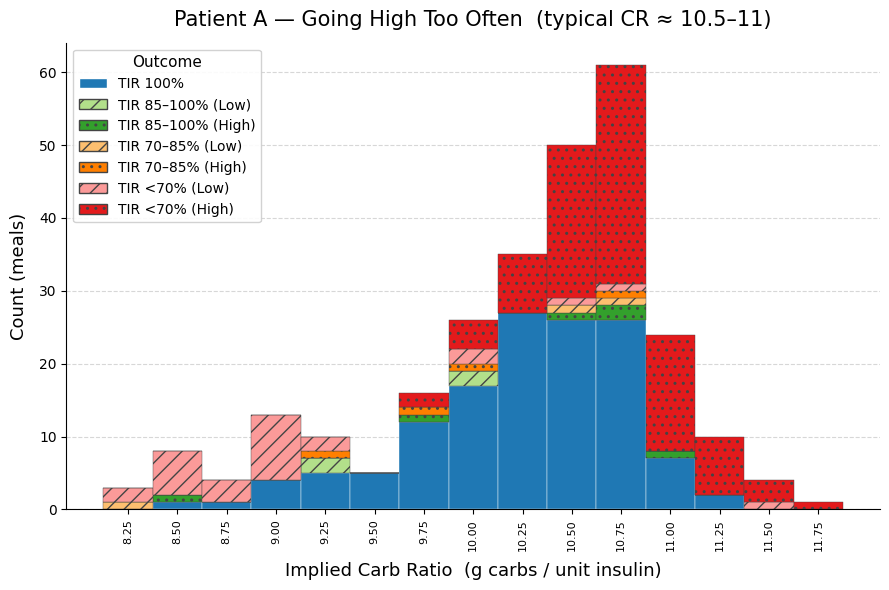

In [141]:
# ── Patient A: Going High Too Often ─────────────────────────────────────────
# This patient's meals cluster around ICR 10.5–11 (underdosing insulin).
# Higher CR → less insulin per carb → post-meal glucose trends high.
make_patient_chart(
    pop_centers=[
        # (mean_icr, mean_glucose, n, sd_icr, sd_glucose)
        (10.75, 162, 180, 0.35, 5),  # dominant cluster: underdosing → goes high
        (10.0, 125, 60, 0.50, 5),  # occasional well-dosed meals
        (9.0, 88, 30, 0.35, 4),  # rare overcorrections → goes low
    ],
    title="Patient A — Going High Too Often  (typical CR ≈ 10.5–11)",
    seed=17,
)

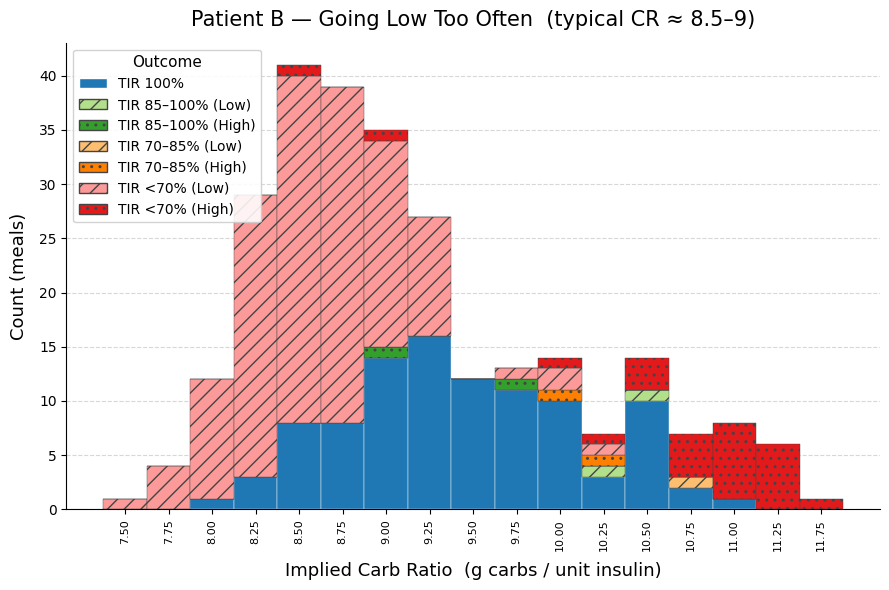

In [142]:
# ── Patient B: Going Low Too Often ──────────────────────────────────────────
# This patient's meals cluster around ICR 8.5–9 (overdosing insulin).
# Lower CR → more insulin per carb → post-meal glucose trends low.
make_patient_chart(
    pop_centers=[
        # (mean_icr, mean_glucose, n, sd_icr, sd_glucose)
        (8.75, 88, 180, 0.35, 4),  # dominant cluster: overdosing → goes low
        (10.0, 125, 60, 0.50, 5),  # occasional well-dosed meals
        (11.0, 162, 30, 0.35, 5),  # rare under-corrections → goes high
    ],
    title="Patient B — Going Low Too Often  (typical CR ≈ 8.5–9)",
    seed=55,
)